In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/SmartChef/Fruit_Images_Dataset.zip', 'r') as z:
    z.extractall('/content/Fruit_Images_Dataset')

with zipfile.ZipFile('/content/drive/MyDrive/SmartChef/freiburg_groceries_dataset.zip', 'r') as z:
    z.extractall('/content/freiburg_groceries_dataset')

In [3]:
import os                    # for working with folders and file paths
import shutil                # for copying files (used when merging the datasets)
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf          # the main deep learning library
from tensorflow import keras     # high level tool inside tensorflow, easier to use
from tensorflow.keras import layers  # the building blocks of our CNN model


print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [4]:
DATASET_1_PATH = '/content/Fruit_Images_Dataset/Fruit_Images_Dataset/Images'
DATASET_2_PATH = '/content/freiburg_groceries_dataset/freiburg_groceries_dataset/images'

#the merged folder will be created automatically in the next step
MERGED_PATH = '/content/merged_dataset'

IMG_SIZE   = (224, 224)  #all images will be resized to this size
BATCH_SIZE = 32          #how many images the model sees at once during training
EPOCHS     = 10          #how many times the model goes through the full training data
RANDOM_SEED = 42         #keeps the data split the same every time we run the code

In [5]:
#this function copies all category folders from both datasets into one combined folder
def merge_datasets(source_paths, destination):

    os.makedirs(destination, exist_ok=True)  #create the merged folder if it doesn't exist

    for source in source_paths:
        for category in os.listdir(source):
            src_category_path = os.path.join(source, category)

            #skip anything that is not a folder (like readme files etc.)
            if not os.path.isdir(src_category_path):
                continue

            dst_category_path = os.path.join(destination, category)
            os.makedirs(dst_category_path, exist_ok=True)

            #copy each image into the matching category folder
            for image_file in os.listdir(src_category_path):
                src_file = os.path.join(src_category_path, image_file)
                dst_file = os.path.join(dst_category_path, image_file)

                #if a file with the same name already exists, add a small prefix to avoid overwriting
                if os.path.exists(dst_file):
                    base, ext = os.path.splitext(image_file)
                    dst_file = os.path.join(dst_category_path, f"ds2_{base}{ext}")

                shutil.copy2(src_file, dst_file)

        print(f'Done copying: {source}')

    categories = sorted(os.listdir(destination))
    print(f'\nTotal categories: {len(categories)}')
    print('Categories:', categories)


#run the merge
merge_datasets([DATASET_1_PATH, DATASET_2_PATH], MERGED_PATH)

Done copying: /content/Fruit_Images_Dataset/Fruit_Images_Dataset/Images
Done copying: /content/freiburg_groceries_dataset/freiburg_groceries_dataset/images

Total categories: 62
Categories: ['Apple', 'Avocado', 'BEANS', 'Banana', 'Beetroot', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'Cauliflower', 'Cherry', 'Chestnut', 'Clementine', 'Corn', 'Dates', 'Eggplant', 'FISH', 'FLOUR', 'Ginger Root', 'Grape', 'Grapefruit', 'HONEY', 'Hazelnut', 'JAM', 'JUICE', 'Kohlrabi', 'Lemon', 'Limes', 'MILK', 'Mandarine', 'Mango', 'NUTS', 'Nectarine', 'Nut Pecan', 'OIL', 'Onion', 'Orange', 'PASTA', 'Peach', 'Pear', 'Pepper', 'Pineapple', 'Plum', 'Pomegranate', 'Potato', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'Strawberry', 'Sweet Potato', 'TEA', 'TOMATO_SAUCE', 'Tomato', 'Tomato Cherry Red', 'VINEGAR', 'WATER', 'Walnut', 'Watermelon']


In [6]:
#load all images from the merged folder
#keras automatically reads the subfolders and uses their names as category labels
full_dataset = keras.utils.image_dataset_from_directory(
    MERGED_PATH,
    image_size=IMG_SIZE,
    batch_size=None,       #load one by one so we can split manually later
    shuffle=True,          #mix the images so the model doesn't see them in order
    seed=RANDOM_SEED,
    label_mode='int'       #each category gets a number: 0, 1, 2 ... 62
)

CLASS_NAMES = full_dataset.class_names  #list of all 63 category names
NUM_CLASSES = len(CLASS_NAMES)          #63

print('Total categories loaded:', NUM_CLASSES)
print('Categories:', CLASS_NAMES)

Found 26789 files belonging to 62 classes.
Total categories loaded: 62
Categories: ['Apple', 'Avocado', 'BEANS', 'Banana', 'Beetroot', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'Cauliflower', 'Cherry', 'Chestnut', 'Clementine', 'Corn', 'Dates', 'Eggplant', 'FISH', 'FLOUR', 'Ginger Root', 'Grape', 'Grapefruit', 'HONEY', 'Hazelnut', 'JAM', 'JUICE', 'Kohlrabi', 'Lemon', 'Limes', 'MILK', 'Mandarine', 'Mango', 'NUTS', 'Nectarine', 'Nut Pecan', 'OIL', 'Onion', 'Orange', 'PASTA', 'Peach', 'Pear', 'Pepper', 'Pineapple', 'Plum', 'Pomegranate', 'Potato', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'Strawberry', 'Sweet Potato', 'TEA', 'TOMATO_SAUCE', 'Tomato', 'Tomato Cherry Red', 'VINEGAR', 'WATER', 'Walnut', 'Watermelon']


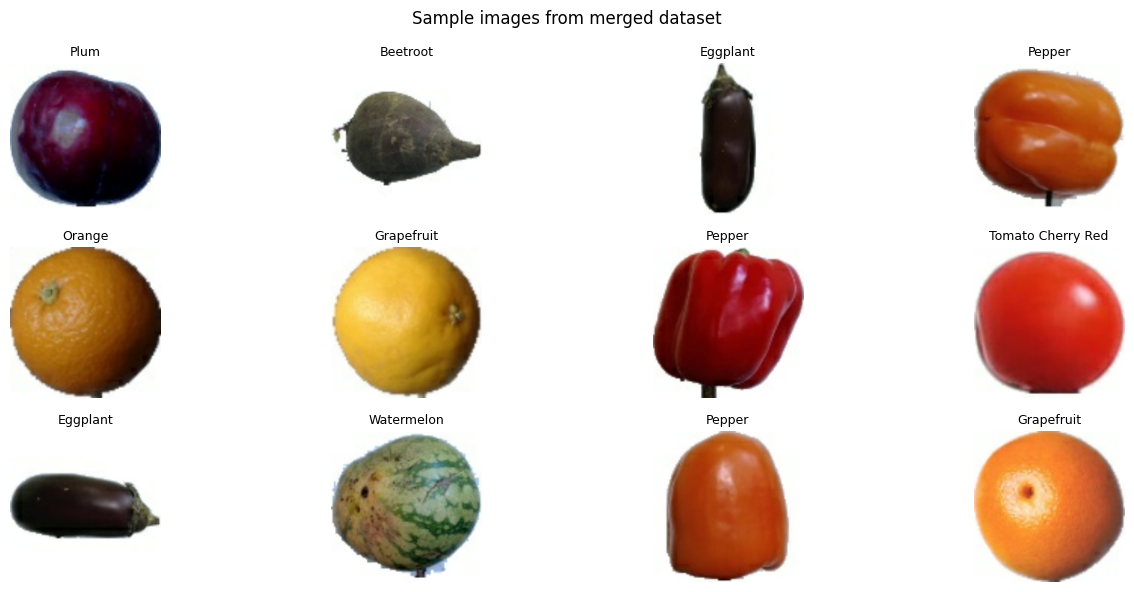

In [7]:
#show 12 random images from the dataset so we can visually confirm everything looks correct
plt.figure(figsize=(14, 6))

for i, (image, label) in enumerate(full_dataset.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(CLASS_NAMES[label.numpy()], fontsize=9)
    plt.axis('off')

plt.suptitle('Sample images from merged dataset')
plt.tight_layout()
plt.show()

In [8]:
#count how many images we have in total
total_images = len(full_dataset)
print('Total images:', total_images)

#calculate how many go into each set
train_size = int(total_images * 0.70)  # 70% for training
val_size   = int(total_images * 0.15)  # 15% for validation
test_size  = total_images - train_size - val_size  # 15% for testing

print(f'Train: {train_size} | Validation: {val_size} | Test: {test_size}')

#split the dataset
train_ds = full_dataset.take(train_size)
val_ds   = full_dataset.skip(train_size).take(val_size)
test_ds  = full_dataset.skip(train_size + val_size)

#batch and prefetch makes training faster
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Split done!')

Total images: 26789
Train: 18752 | Validation: 4018 | Test: 4019
Split done!


In [10]:
# load MobileNetV2 pretrained on imagenet, without its top classification layer
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,       # remove the original 1000-class output
    weights='imagenet'       # use pretrained weights
)
base_model.trainable = False  # freeze pretrained layers, don't retrain them

# build our model on top
model = keras.Sequential([
    # data augmentation helps the model handle real-world photos
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # MobileNetV2 expects pixels in range [-1, 1]
    layers.Lambda(lambda x: keras.applications.mobilenet_v2.preprocess_input(x)),

    # the pretrained base
    base_model,

    # convert feature maps to a single vector
    layers.GlobalAveragePooling2D(),

    # dropout to avoid overfitting
    layers.Dropout(0.3),

    # our output layer - one node per food category
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
#compile the model - tell it how to learn
model.compile(
    optimizer='adam',              #adam is the most common optimizer, works well in most cases
    loss='sparse_categorical_crossentropy',  #standard loss function for multi-class classification
    metrics=['accuracy']           #we want to see accuracy after each epoch
)

#start training!
history = model.fit(
    train_ds,                      #the training data
    epochs=EPOCHS,                 #how many times to go through all the training images
    validation_data=val_ds         #check performance on validation set after each epoch
)

Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 1064s 2s/step - accuracy: 0.8151 - loss: 0.7291 - val_accuracy: 0.9171 - val_loss: 0.3023
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 780s 1s/step - accuracy: 0.9172 - loss: 0.2901 - val_accuracy: 0.9350 - val_loss: 0.2313
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 747s 1s/step - accuracy: 0.9323 - loss: 0.2308 - val_accuracy: 0.9355 - val_loss: 0.2093
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 753s 1s/step - accuracy: 0.9386 - loss: 0.2013 - val_accuracy: 0.9423 - val_loss: 0.1928
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.9407 - loss: 0.1890 - val_accuracy: 0.9408 - val_loss: 0.2051
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 776s 1s/step - accuracy: 0.9482 - loss: 0.1699 - val_accuracy: 0.9475 - val_loss: 0.1798
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 792s 1s/step - accuracy: 0.9493 - loss: 0.1680 - val_accuracy: 0.9383 - val_loss: 0.1981
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 806s 1s/step - accuracy: 0.9505 - loss: 0.1564 - val_acc

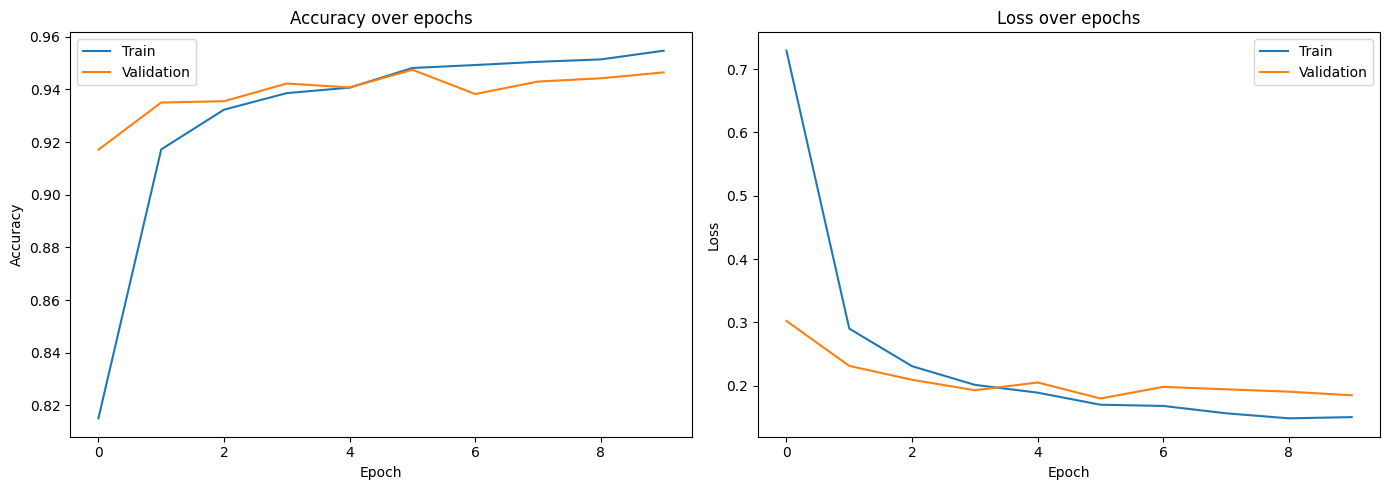

In [12]:
# plot training results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)

print(f'Test Loss: {round(test_loss, 4)}')
print(f'Test Accuracy: {round(test_accuracy * 100, 2)}%')

126/126 ━━━━━━━━━━━━━━━━━━━━ 126s 868ms/step - accuracy: 0.9435 - loss: 0.2001
Test Loss: 0.2001
Test Accuracy: 94.35%


In [14]:
# save to Drive
model.save('/content/drive/MyDrive/SmartChef/food_classifier_model.keras')

# also save the class names so we don't need to reload the dataset next time
import json
with open('/content/drive/MyDrive/SmartChef/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

print('Model and class names saved!')

Model and class names saved!


In [15]:
#Accuracy
from sklearn.metrics import accuracy_score

# get predictions on the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {round(accuracy * 100, 2)}%')

Accuracy: 94.68%


In [16]:
#Precision, Recall, F1 Score
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

                   precision    recall  f1-score   support

            Apple       1.00      1.00      1.00       146
          Avocado       1.00      1.00      1.00        62
            BEANS       0.46      0.79      0.58        14
           Banana       1.00      1.00      1.00        78
         Beetroot       1.00      1.00      1.00        65
             CAKE       0.84      0.76      0.80        21
            CANDY       0.73      0.83      0.78        48
           CEREAL       0.63      0.76      0.69        38
            CHIPS       0.83      0.61      0.70        31
        CHOCOLATE       0.60      0.91      0.72        43
           COFFEE       0.69      0.29      0.41        31
             CORN       0.78      1.00      0.88        14
      Cauliflower       1.00      1.00      1.00       113
           Cherry       1.00      1.00      1.00        76
         Chestnut       1.00      1.00      1.00        73
       Clementine       1.00      1.00      1.00       

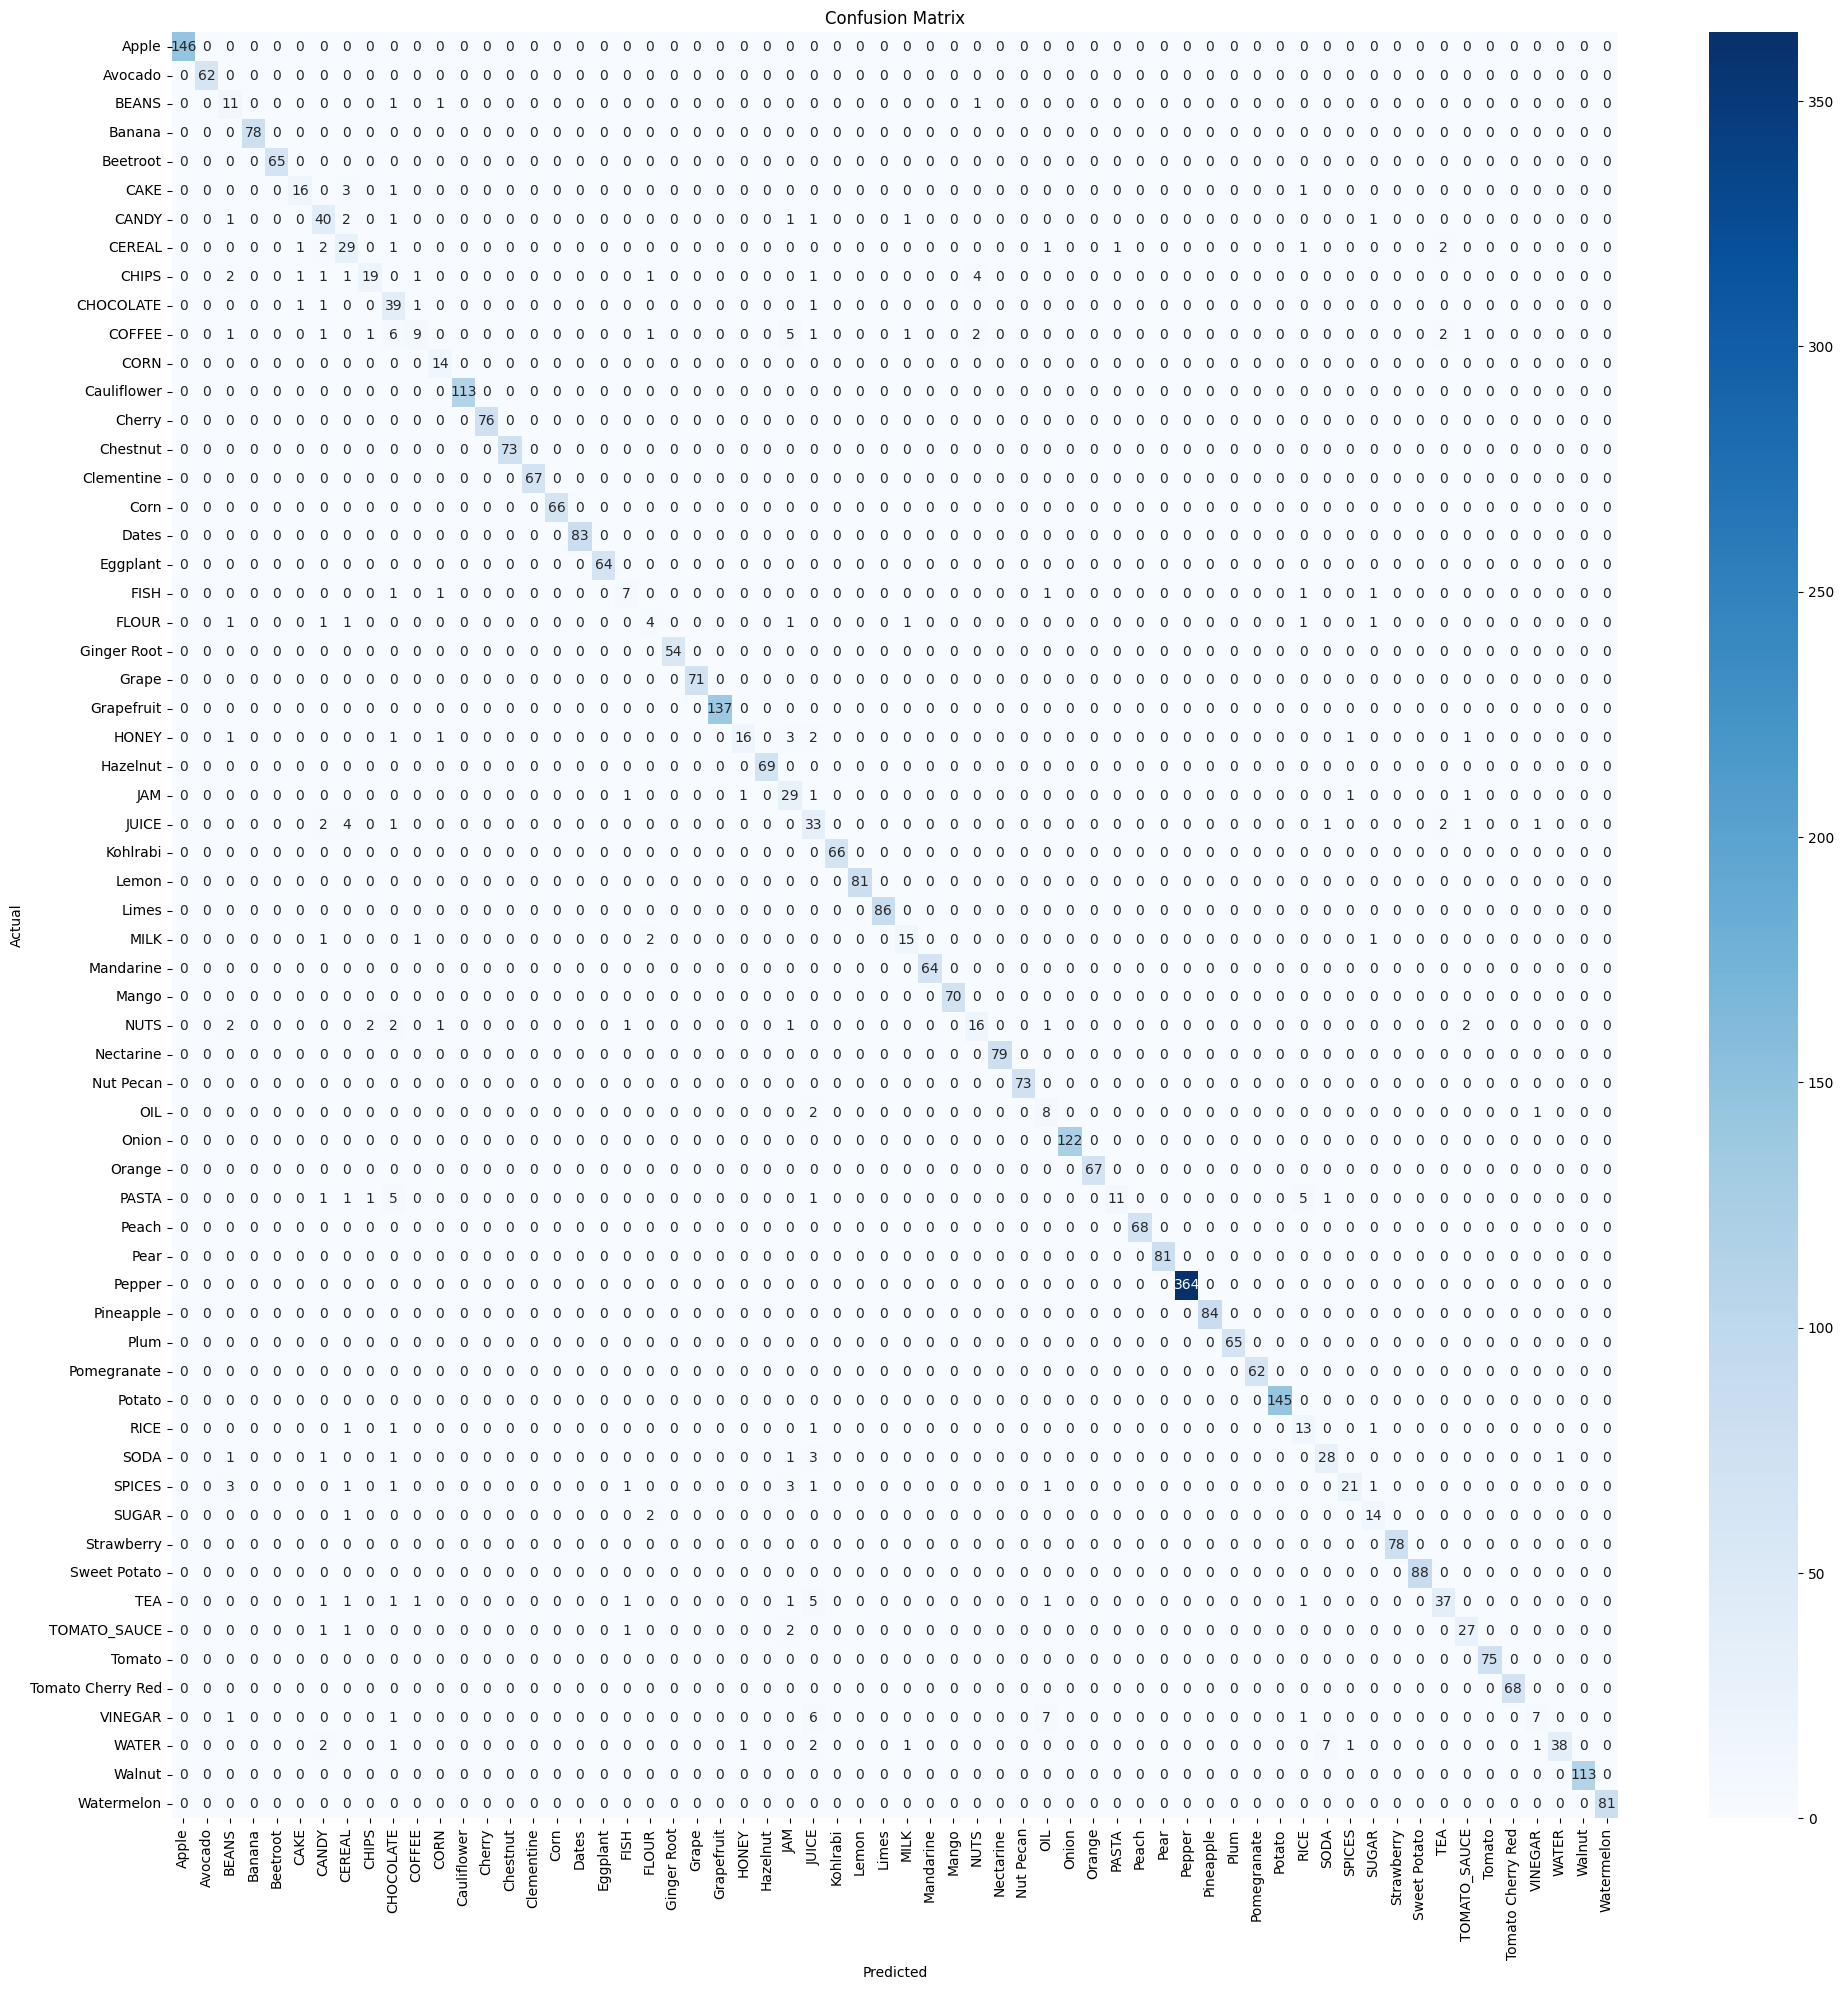

In [17]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()